In [73]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions


In [36]:
df = pd.read_csv("../Final_data/songs_features.csv")
df.head()

,name,tempo,beat_strength,energy_mean,energy_std,dynamic_range,chroma_mean,chroma_std,spectral_centroid,spectral_contrast,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,zcr_mean,label
0,Everyday Life,123.046875,0.981157,0.025713,0.014985,0.083676,0.408541,0.258434,1537.731119,23.296503,...,-8.680209,6.275540,-15.094731,6.271287,-0.864311,7.043264,-0.788505,6.942981,0.098072,0
1,Burden In My Hand,123.046875,1.336275,0.041835,0.017012,0.068825,0.459583,0.265205,2551.869913,22.234506,...,-3.696764,8.544387,-3.825223,8.088765,-3.495393,8.881334,-9.999342,8.534403,0.147812,0
2,Pyramid Song,67.999589,0.953440,0.128004,0.069231,0.303919,0.288982,0.279187,839.823618,23.027056,...,-7.560100,6.494928,-10.212765,6.018681,-8.773573,5.335854,-8.033224,5.323475,0.036183,0
3,On The Mend,135.999178,1.201808,0.222142,0.058195,0.413075,0.316370,0.253531,1527.738359,24.206465,...,3.848006,7.888925,-13.473984,8.385788,1.724091,5.559725,-0.029374,6.815355,0.045591,1
4,Mica Van Gogh,103.359375,1.279580,0.159782,0.052167,0.287848,0.525016,0.246945,3453.818105,20.013816,...,3.799896,7.767109,-0.058388,7.153408,2.393339,7.260057,-3.228938,6.573883,0.191171,1


In [104]:
X = df.drop(columns=["name", "label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [46]:
scores = []
clist = [0.01, 0.1, 0.5, 1, 5, 10, 100]
for C in clist:
    svm = SVC(C=C, kernel="rbf", gamma="scale", class_weight="balanced")
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    scores.append(score)

In [47]:
for i in range(len(clist)):
    print(clist[i], scores[i])

0.01 0.6666666666666666
0.1 0.6666666666666666
0.5 0.6666666666666666
1 0.6666666666666666
5 0.5555555555555556
10 0.5555555555555556
100 0.5555555555555556


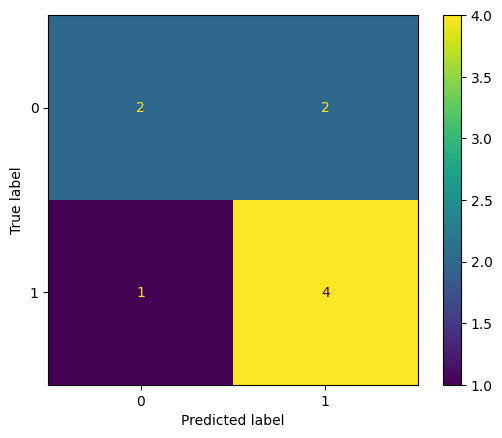

In [48]:
svm_rbf = SVC(C=0.01, kernel="rbf", gamma="scale", class_weight="balanced")
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rbf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [49]:
scores_2 = []
for C in clist:
    svm = SVC(C=C, kernel="poly", gamma="scale", class_weight="balanced")
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    scores_2.append(score)

In [50]:
for i in range(len(clist)):
    print(clist[i], scores_2[i])

0.01 0.4444444444444444
0.1 0.4444444444444444
0.5 0.6666666666666666
1 0.6666666666666666
5 0.4444444444444444
10 0.4444444444444444
100 0.3333333333333333


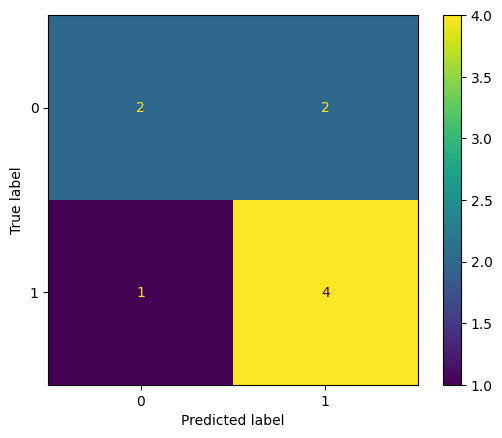

In [54]:
svm_poly = SVC(C=0.5, kernel="poly", gamma="scale", class_weight="balanced")
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)

cm = confusion_matrix(y_test, y_pred_poly)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [59]:
scores_3 = []
for C in clist:
    svm = SVC(C=C, kernel="sigmoid", gamma="scale", class_weight="balanced")
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    scores_3.append(score)

In [60]:
for i in range(len(clist)):
    print(clist[i], scores_3[i])

0.01 0.3333333333333333
0.1 0.3333333333333333
0.5 0.5555555555555556
1 0.6666666666666666
5 0.3333333333333333
10 0.3333333333333333
100 0.3333333333333333


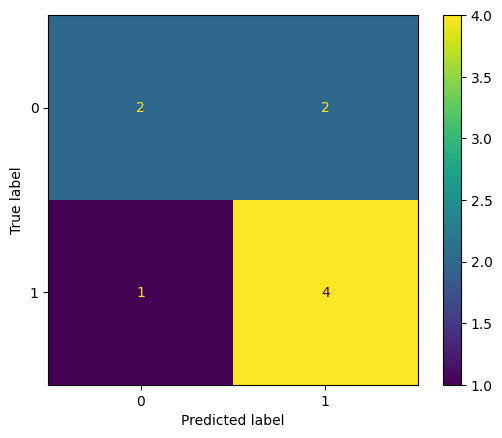

In [61]:
svm_sig = SVC(C=1, kernel="sigmoid", gamma="scale", class_weight="balanced")
svm_sig.fit(X_train, y_train)
y_pred_sig = svm_sig.predict(X_test)

cm = confusion_matrix(y_test, y_pred_sig)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [62]:
X = df[["energy_std", "tempo"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [63]:
scores = []
clist = [0.01, 0.1, 0.5, 1, 5, 10, 100]
for C in clist:
    svm = SVC(C=C, kernel="rbf", gamma="scale", class_weight="balanced")
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    scores.append(score)

In [64]:
for i in range(len(clist)):
    print(clist[i], scores[i])

0.01 0.7777777777777778
0.1 0.7777777777777778
0.5 0.7777777777777778
1 0.8888888888888888
5 0.8888888888888888
10 0.8888888888888888
100 0.6666666666666666


Text(0.5, 1.0, 'Confusion Matrix (RBF SVM)')

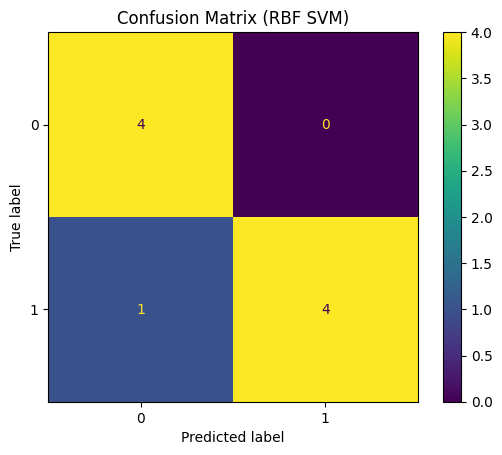

In [90]:
svm_rbf = SVC(C=1, kernel="rbf", gamma="scale", class_weight="balanced")
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rbf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot().ax_.set_title("Confusion Matrix (RBF SVM)")

In [67]:
scores_2 = []
for C in clist:
    svm = SVC(C=C, kernel="poly", gamma="scale", class_weight="balanced")
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    scores_2.append(score)

for i in range(len(clist)):
    print(clist[i], scores_2[i])

0.01 0.4444444444444444
0.1 0.5555555555555556
0.5 0.4444444444444444
1 0.4444444444444444
5 0.5555555555555556
10 0.5555555555555556
100 0.4444444444444444


Text(0.5, 1.0, 'Confusion Matrix (Polynomial SVM)')

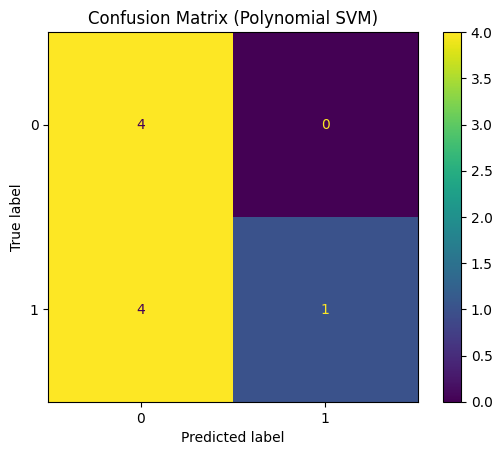

In [89]:
svm_poly = SVC(C=0.1, kernel="poly", gamma="scale", class_weight="balanced")
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)

cm = confusion_matrix(y_test, y_pred_poly)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot().ax_.set_title("Confusion Matrix (Polynomial SVM)")

In [70]:
scores_3 = []
for C in clist:
    svm = SVC(C=C, kernel="sigmoid", gamma="scale", class_weight="balanced")
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    scores_3.append(score)

for i in range(len(clist)):
    print(clist[i], scores_3[i])

0.01 0.6666666666666666
0.1 0.6666666666666666
0.5 0.4444444444444444
1 0.5555555555555556
5 0.5555555555555556
10 0.5555555555555556
100 0.6666666666666666


Text(0.5, 1.0, 'Confusion Matrix (Sigmoid SVM)')

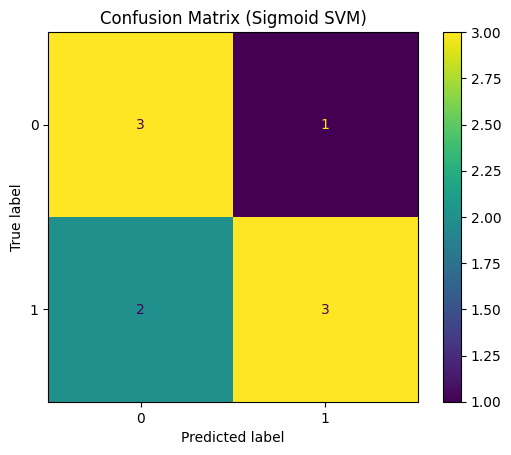

In [88]:
svm_sig = SVC(C=0.1, kernel="sigmoid", gamma="scale", class_weight="balanced")
svm_sig.fit(X_train, y_train)
y_pred_sig = svm_sig.predict(X_test)

cm = confusion_matrix(y_test, y_pred_sig)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot().ax_.set_title("Confusion Matrix (Sigmoid SVM)")

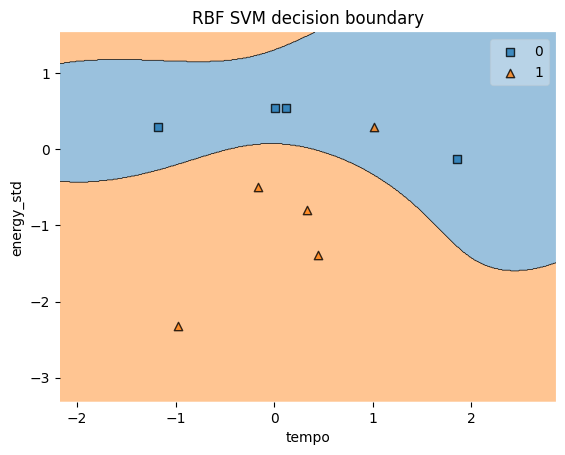

In [ ]:
plot_decision_regions(X_test, np.array(y_test), clf=svm_rbf)
plt.xlabel("tempo")
plt.ylabel("energy_std")
plt.title("RBF SVM decision boundary")
plt.show()

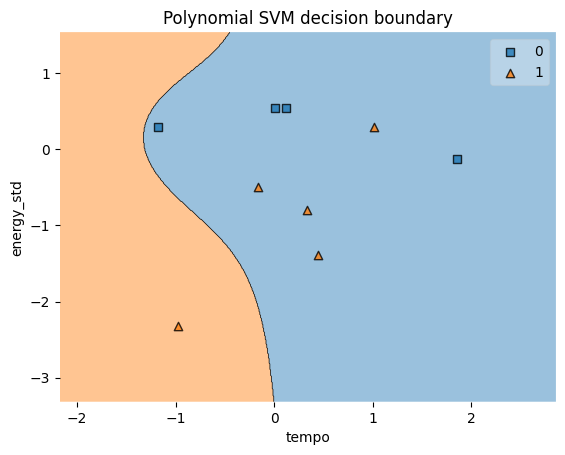

In [ ]:
plot_decision_regions(X_test, np.array(y_test), clf=svm_poly)
plt.xlabel("tempo")
plt.ylabel("energy_std")
plt.title("Polynomial SVM decision boundary")
plt.show()

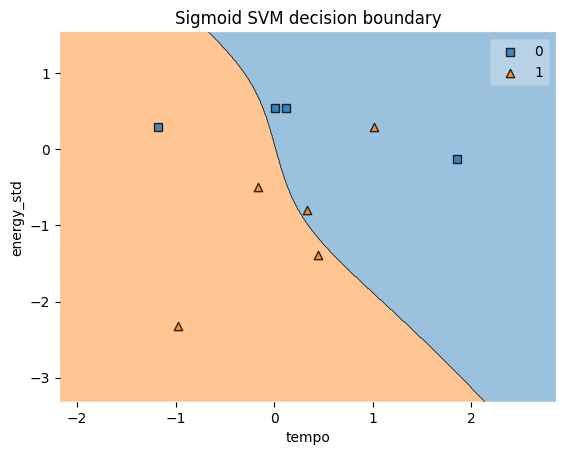

In [ ]:
plot_decision_regions(X_test, np.array(y_test), clf=svm_sig)
plt.xlabel("tempo")
plt.ylabel("energy_std")
plt.title("Sigmoid SVM decision boundary")
plt.show()

In [101]:
df[["tempo", "energy_std", "label"]].to_csv("../Final_data/filtered_df.csv")

In [103]:
df.columns

Index(['name', 'tempo', 'beat_strength', 'energy_mean', 'energy_std',
       'dynamic_range', 'chroma_mean', 'chroma_std', 'spectral_centroid',
       'spectral_contrast', 'spectral_rolloff', 'spectral_flatness',
       'mfcc_0_mean', 'mfcc_0_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean',
       'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std',
       'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean',
       'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std',
       'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std',
       'mfcc_12_mean', 'mfcc_12_std', 'zcr_mean', 'label'],
      dtype='object')

In [106]:
X_test

array([[ 0.1657031 , -0.0735495 , -0.64593744,  0.40937397,  0.13942673,
        -0.58860994,  0.10925214,  0.61071869,  0.234564  ,  0.6148897 ,
        -0.27590056,  0.12195654,  0.79549478, -0.52483783, -0.67637936,
        -0.41179611,  0.12456704,  0.03245157,  0.96758021, -0.64132006,
        -0.99625272,  0.01201827, -0.23179476, -0.48304268, -0.0960384 ,
        -0.35453185,  1.99552344, -0.05014782,  0.14246496,  0.17877949,
        -0.24197454,  0.68054297, -0.83297643,  0.48459269, -0.01309902,
         0.90066304,  0.97716876,  0.54918234],
       [ 0.38845978, -0.77292451, -1.40648471, -1.39075196, -1.53115694,
         0.2708788 , -0.73926189, -0.45392944, -0.1642992 , -0.7568126 ,
        -0.5706246 , -0.92041658, -0.25260565,  0.83179803, -1.26927821,
        -1.74163353, -1.10753059, -1.39855561, -1.04916536, -1.60463007,
        -1.16329934, -2.54835357, -0.79649904, -2.5988374 , -1.32220832,
        -1.80946729, -1.28542139, -1.31017495, -1.33983321, -1.35474127,
   